In [ ]:
# 01_non_personalized.ipynb

## 0. Contributors
## 1. Objective
## 2. Imports and Data Loading
## 3. Data Preparation
## 4. Exploratory Data Analysis
## 5. Train/Test Split
## 6. Non-personalized recommenders
## 7. Evaluation

#**0. Contributors**
- Jacobo Galindo Sanz


#**1. Objective**

The objective of this notebook is to implement non-personalized recommendation models as baseline approaches to establish a reference point for evaluating more advanced techniques. These models do not incorporate individual user preferences but instead rely on global patterns observed in the dataset.



#**2. Imports and Data Loading**


In [ ]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

In [ ]:
#Data loading
orders = pd.read_csv("orders.csv")
order_products_prior = pd.read_csv("order_products__prior.csv")
products = pd.read_csv("products.csv")
aisles = pd.read_csv("aisles.csv")
departments = pd.read_csv("departments.csv")

In [ ]:
#Size of datasets
for name, df in [
    ("orders", orders),
    ("order_products_prior", order_products_prior),
    ("products", products),
    ("aisles", aisles),
    ("departments", departments),
]:
    print(f"{name}: {df.shape}")

orders: (1007821, 7)
order_products_prior: (2632103, 4)
products: (49688, 4)
aisles: (134, 2)
departments: (21, 2)


#**3. Data Preparation**


In [ ]:
#Merge: products with aisle and department
products_full = (
    products
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
)

products_full.head()

,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry


In [ ]:
#Merge: prior orders with orders and products
prior = (
    order_products_prior
    .merge(orders, on="order_id", how="left")
    .merge(products_full, on="product_id", how="left")
)

prior.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,Natural Sweetener,17,13,baking ingredients,pantry


In [ ]:
#Check columns
print(prior.columns.tolist())

['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department']


#**4. Exploratory Data Analysis**


In [ ]:
#Size of the problem
n_users = prior["user_id"].nunique()
n_products = prior["product_id"].nunique()
n_orders = prior["order_id"].nunique()
n_interactions = len(prior)

print("Users:", n_users)
print("Products:", n_products)
print("Orders:", n_orders)
print("Interactions:", n_interactions)

Users: 34717
Products: 42339
Orders: 260733
Interactions: 2632103


In [ ]:
#Sparsity
sparsity = 1 - (n_interactions / (n_users * n_products))
print(f"Sparsity: {sparsity:.2%}")

Sparsity: 99.82%


In [ ]:
#Top products
top_products = (
    prior.groupby(["product_id", "product_name"])
    .size()
    .reset_index(name="purchase_count")
    .sort_values("purchase_count", ascending=False)
    .head(15)
)

top_products

,product_id,product_name,purchase_count
21159,24852,Banana,38650
11154,13176,Bag of Organic Bananas,30667
17968,21137,Organic Strawberries,21356
18633,21903,Organic Baby Spinach,19634
40213,47209,Organic Hass Avocado,17186
40698,47766,Organic Avocado,14212
40577,47626,Large Lemon,12420
14246,16797,Strawberries,11642
22298,26209,Limes,11433
23674,27845,Organic Whole Milk,11147


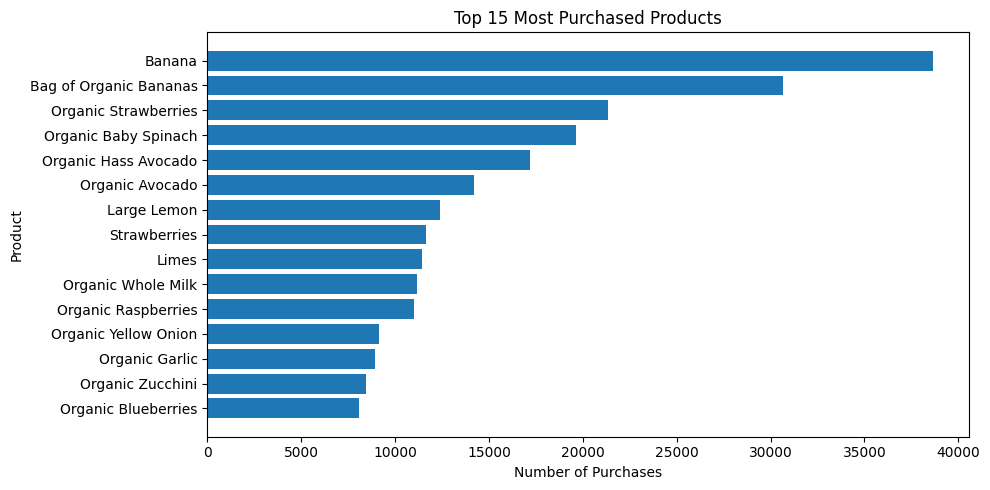

In [ ]:
plt.figure(figsize=(10, 5))
plt.barh(top_products["product_name"][::-1], top_products["purchase_count"][::-1])
plt.title("Top 15 Most Purchased Products")
plt.xlabel("Number of Purchases")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [ ]:
#Purchases per user
user_activity = prior.groupby("user_id").size()

print(user_activity.describe())

count    34717.000000
mean        22.207535
std         24.241711
min          1.000000
25%          7.000000
50%         14.000000
75%         28.000000
max        375.000000
dtype: float64


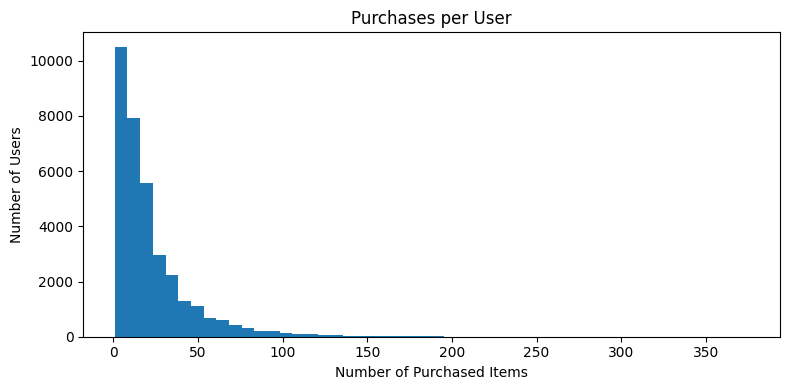

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(user_activity, bins=50)
plt.title("Purchases per User")
plt.xlabel("Number of Purchased Items")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

In [ ]:
#Product popularity
product_popularity = prior.groupby("product_id").size()

print(product_popularity.describe())

count    42339.000000
mean        62.167340
std        420.464905
min          1.000000
25%          2.000000
50%          7.000000
75%         28.000000
max      38650.000000
dtype: float64


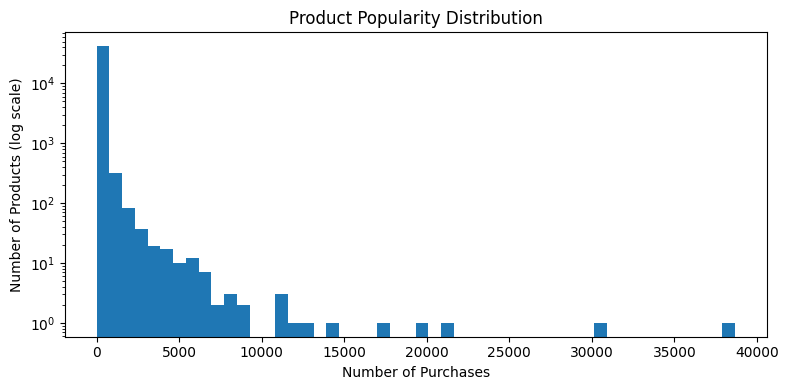

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(product_popularity, bins=50)
plt.yscale("log")
plt.title("Product Popularity Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Products (log scale)")
plt.tight_layout()
plt.show()

In [ ]:
#Reorder rate
print("Global reorder rate:", prior["reordered"].mean())

Global reorder rate: 0.5898802554004366


#**5. Train/Test Split**


In [ ]:
# --- SAFE SPLIT BLOCK (can be re-run multiple times) ---

# Work on a clean copy to avoid merge issues
prior_split = prior.copy()

# Remove column if it already exists (prevents merge error)
if "last_order_number" in prior_split.columns:
    prior_split = prior_split.drop(columns=["last_order_number"])

# Last order per user
user_last_order = (
    prior_split.groupby("user_id")["order_number"]
    .max()
    .reset_index()
)

user_last_order.columns = ["user_id", "last_order_number"]

# Merge safely
prior_split = prior_split.merge(user_last_order, on="user_id", how="left")

# Train / Test split
train_df = prior_split[prior_split["order_number"] < prior_split["last_order_number"]].copy()
test_df = prior_split[prior_split["order_number"] == prior_split["last_order_number"]].copy()

# Keep only users present in train
valid_users = train_df["user_id"].unique()
test_df = test_df[test_df["user_id"].isin(valid_users)].copy()

# Keep only users present in both train and test (clean evaluation)
train_users = set(train_df["user_id"].unique())
test_users = set(test_df["user_id"].unique())
common_users = train_users.intersection(test_users)

train_df = train_df[train_df["user_id"].isin(common_users)].copy()
test_df = test_df[test_df["user_id"].isin(common_users)].copy()

# Print stats
print("Train interactions:", len(train_df))
print("Test interactions:", len(test_df))
print("Train users:", train_df["user_id"].nunique())
print("Test users:", test_df["user_id"].nunique())

Train interactions: 417303
Test interactions: 185491
Train users: 17832
Test users: 17832


In [ ]:
# Ground truth per user
ground_truth = (
    test_df.groupby("user_id")["product_id"]
    .apply(set)
    .to_dict()
)

print("Users in ground truth:", len(ground_truth))

Users in ground truth: 17832


#**6. Non-Personalized Recommenders**


###**6.1 Most popular (basic baseline)**


In [ ]:
# Global popularity
global_popularity = (
    train_df.groupby(["product_id", "product_name"])
    .size()
    .reset_index(name="purchase_count")
    .sort_values("purchase_count", ascending=False)
)

global_popularity.head(10)

,product_id,product_name,purchase_count
13014,24852,Banana,6305
6860,13176,Bag of Organic Bananas,5112
11062,21137,Organic Strawberries,3745
11468,21903,Organic Baby Spinach,3187
24792,47209,Organic Hass Avocado,3037
25078,47766,Organic Avocado,2209
14568,27845,Organic Whole Milk,1860
14634,27966,Organic Raspberries,1851
25010,47626,Large Lemon,1818
13729,26209,Limes,1816


In [ ]:
# Recommendation list
popular_products = global_popularity["product_id"].tolist()

def recommend_most_popular(k=10):
    return popular_products[:k]

###**6.2 Top Reorder Rate**


In [ ]:
reorder_stats = (
    train_df.groupby(["product_id", "product_name"])
    .agg(
        reorder_rate=("reordered", "mean"),
        purchase_count=("product_id", "count")
    )
    .reset_index()
)

# Combine both signals
reorder_stats["score"] = (
    reorder_stats["reorder_rate"] *
    np.log1p(reorder_stats["purchase_count"])
)

reorder_stats = reorder_stats.sort_values("score", ascending=False)

reorder_stats.head(10)

,product_id,product_name,reorder_rate,purchase_count,score
13014,24852,Banana,0.854877,6305,7.479539
6860,13176,Bag of Organic Bananas,0.841941,5112,7.189786
11062,21137,Organic Strawberries,0.795461,3745,6.545403
24792,47209,Organic Hass Avocado,0.813303,3037,6.521837
11468,21903,Organic Baby Spinach,0.791654,3187,6.386388
14568,27845,Organic Whole Milk,0.846774,1860,6.375252
25078,47766,Organic Avocado,0.769126,2209,5.922848
14634,27966,Organic Raspberries,0.768774,1851,5.784269
25866,49235,Organic Half & Half,0.803213,996,5.545985
14184,27086,Half & Half,0.795574,949,5.454825


In [ ]:
top_reorder_products = reorder_stats["product_id"].tolist()

def recommend_top_reorder(k=10):
    return top_reorder_products[:k]

###**6.3 Weighted Reorder Score**


In [ ]:
# 6.3 Bayesian Weighted Reorder Score

# Step 1: Compute product-level stats
bayesian_stats = (
    train_df.groupby(["product_id", "product_name"])
    .agg(
        purchase_count=("product_id", "count"),
        reorder_rate=("reordered", "mean")
    )
    .reset_index()
)

# Step 2: Global average reorder rate across all products
C = bayesian_stats["reorder_rate"].mean()

# Step 3: Minimum votes / confidence threshold
# Good practice: use a percentile of purchase counts
m = bayesian_stats["purchase_count"].quantile(0.9)

print(f"Global average reorder rate (C): {C:.4f}")
print(f"Minimum purchase threshold (m): {m:.0f}")

# Step 4: Bayesian weighted score
bayesian_stats["bayesian_score"] = (
    (bayesian_stats["purchase_count"] / (bayesian_stats["purchase_count"] + m)) * bayesian_stats["reorder_rate"]
    + (m / (bayesian_stats["purchase_count"] + m)) * C
)

# Step 5: Rank products
bayesian_stats = bayesian_stats.sort_values("bayesian_score", ascending=False)

# Show top results
bayesian_stats.head(10)

Global average reorder rate (C): 0.4478
Minimum purchase threshold (m): 28


,product_id,product_name,purchase_count,reorder_rate,bayesian_score
13014,24852,Banana,6305,0.854877,0.853077
23885,45504,Whole Organic Omega 3 Milk,129,0.937984,0.850566
20280,38689,Organic Reduced Fat Milk,471,0.872611,0.848775
14568,27845,Organic Whole Milk,1860,0.846774,0.840857
15434,29447,"Milk, Organic, Vitamin D",276,0.880435,0.840588
6860,13176,Bag of Organic Bananas,5112,0.841941,0.839794
17051,32566,Dha Omega 3 Vitamin D Milk,115,0.921739,0.828943
16631,31720,Organic Whole Milk,153,0.895425,0.826181
10536,20082,Organic Whole Milk with DHA Omega-3,197,0.878173,0.824617
18903,36011,Organic Fat Free Milk,395,0.843038,0.816877


In [ ]:
top_bayesian_products = bayesian_stats["product_id"].tolist()

def recommend_bayesian(k=10):
    return top_bayesian_products[:k]

#**7. Evaluation**


In [ ]:
import math
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

In [ ]:
#Metric Functions

def precision_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    if k == 0:
        return 0.0
    return len(set(recommended) & set(relevant)) / k

def recall_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    if len(relevant) == 0:
        return 0.0
    return len(set(recommended) & set(relevant)) / len(set(relevant))

def ndcg_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    dcg = 0.0
    for idx, item in enumerate(recommended, start=1):
        if item in relevant:
            dcg += 1 / math.log2(idx + 1)

    ideal_hits = min(len(set(relevant)), k)
    if ideal_hits == 0:
        return 0.0

    idcg = sum(1 / math.log2(i + 1) for i in range(1, ideal_hits + 1))
    return dcg / idcg

def coverage_at_k(all_recommendations, catalog_size, k=10):
    recommended_items = set()
    for recs in all_recommendations.values():
        recommended_items.update(recs[:k])
    return len(recommended_items) / catalog_size if catalog_size > 0 else 0.0

def intra_list_diversity(recommended, similarity_dict, k=10):
    items = recommended[:k]
    if len(items) < 2:
        return 0.0

    pairwise_sims = []
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            sim = similarity_dict.get((items[i], items[j]), similarity_dict.get((items[j], items[i]), 0.0))
            pairwise_sims.append(sim)

    if len(pairwise_sims) == 0:
        return 0.0

    return 1 - np.mean(pairwise_sims)

def serendipity_at_k(recommended, relevant, popular_set, k=10):
    recommended = recommended[:k]
    hits = [item for item in recommended if item in relevant and item not in popular_set]
    return len(hits) / k if k > 0 else 0.0

In [ ]:
# Score dictionaries (needed for RMSE)

pop_score_dict = dict(zip(global_popularity["product_id"], global_popularity["purchase_count"] / global_popularity["purchase_count"].max()))

reorder_score_dict = dict(zip(reorder_stats["product_id"], reorder_stats["score"]))

bayesian_score_dict = dict(zip(bayesian_stats["product_id"], bayesian_stats["bayesian_score"]))

In [ ]:
# RMSE / MAE Evaluation on Test Set

test_eval = test_df.copy()

test_eval["pred_pop"] = test_eval["product_id"].map(pop_score_dict).fillna(0)
test_eval["pred_reorder"] = test_eval["product_id"].map(reorder_score_dict).fillna(0)
test_eval["pred_bayesian"] = test_eval["product_id"].map(bayesian_score_dict).fillna(0)

y_true = test_eval["reordered"]

rmse_pop = np.sqrt(mean_squared_error(y_true, test_eval["pred_pop"]))
mae_pop = mean_absolute_error(y_true, test_eval["pred_pop"])

rmse_reorder = np.sqrt(mean_squared_error(y_true, test_eval["pred_reorder"]))
mae_reorder = mean_absolute_error(y_true, test_eval["pred_reorder"])

rmse_bayesian = np.sqrt(mean_squared_error(y_true, test_eval["pred_bayesian"]))
mae_bayesian = mean_absolute_error(y_true, test_eval["pred_bayesian"])

print("Most Popular     -> RMSE:", round(rmse_pop, 4), "| MAE:", round(mae_pop, 4))
print("Top Reorder Rate -> RMSE:", round(rmse_reorder, 4), "| MAE:", round(mae_reorder, 4))
print("Weighted Score   -> RMSE:", round(rmse_bayesian, 4), "| MAE:", round(mae_bayesian, 4))

Most Popular     -> RMSE: 0.771 | MAE: 0.6359
Top Reorder Rate -> RMSE: 2.7866 | MAE: 2.2972
Weighted Score   -> RMSE: 0.4603 | MAE: 0.4344


In [ ]:
# User Evaluation

K = 10
results = []

all_recs_pop = {}
all_recs_reorder = {}
all_recs_bayesian = {}

for user_id, relevant_items in ground_truth.items():
    rec_pop = recommend_most_popular(k=K)
    rec_reorder = recommend_top_reorder(k=K)
    rec_bayesian = recommend_bayesian(k=K)

    all_recs_pop[user_id] = rec_pop
    all_recs_reorder[user_id] = rec_reorder
    all_recs_bayesian[user_id] = rec_bayesian

    results.append({
        "user_id": user_id,

        "precision_pop": precision_at_k(rec_pop, relevant_items, K),
        "recall_pop": recall_at_k(rec_pop, relevant_items, K),
        "ndcg_pop": ndcg_at_k(rec_pop, relevant_items, K),

        "precision_reorder": precision_at_k(rec_reorder, relevant_items, K),
        "recall_reorder": recall_at_k(rec_reorder, relevant_items, K),
        "ndcg_reorder": ndcg_at_k(rec_reorder, relevant_items, K),

        "precision_bayesian": precision_at_k(rec_bayesian, relevant_items, K),
        "recall_bayesian": recall_at_k(rec_bayesian, relevant_items, K),
        "ndcg_bayesian": ndcg_at_k(rec_bayesian, relevant_items, K),
    })

results_df = pd.DataFrame(results)
results_df.head()

,user_id,precision_pop,recall_pop,ndcg_pop,precision_reorder,recall_reorder,ndcg_reorder,precision_bayesian,recall_bayesian,ndcg_bayesian
0,7.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000
1,10.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000
2,21.0,0.3,0.176471,0.408536,0.4,0.235294,0.467122,0.1,0.058824,0.220092
3,22.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000
4,24.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000


In [ ]:
#Lightweight diversity using metadata

product_meta = (
    products_full[["product_id", "aisle_id", "department_id"]]
    .drop_duplicates()
    .set_index("product_id")
)

def metadata_diversity_at_k(recommended, product_meta, k=10):
    items = recommended[:k]

    if len(items) < 2:
        return 0.0

    valid_items = [item for item in items if item in product_meta.index]

    if len(valid_items) < 2:
        return 0.0

    pair_scores = []

    for i in range(len(valid_items)):
        for j in range(i + 1, len(valid_items)):
            item_i = valid_items[i]
            item_j = valid_items[j]

            same_aisle = (
                product_meta.loc[item_i, "aisle_id"] ==
                product_meta.loc[item_j, "aisle_id"]
            )

            same_department = (
                product_meta.loc[item_i, "department_id"] ==
                product_meta.loc[item_j, "department_id"]
            )

            # similarity proxy:
            # 1.0 if same aisle
            # 0.5 if same department but different aisle
            # 0.0 if different department
            if same_aisle:
                sim = 1.0
            elif same_department:
                sim = 0.5
            else:
                sim = 0.0

            pair_scores.append(sim)

    if len(pair_scores) == 0:
        return 0.0

    return 1 - np.mean(pair_scores)

In [ ]:
#Popular Set for Serendipity

popular_set = set(global_popularity["product_id"].head(20).tolist())
popular_set

{5876,
 8277,
 13176,
 16797,
 21137,
 21903,
 22935,
 24852,
 24964,
 26209,
 27845,
 27966,
 28204,
 30391,
 39275,
 45007,
 47209,
 47626,
 47766,
 49683}

In [ ]:
# Diversity and Serendipity
diversity_pop = np.mean([
    metadata_diversity_at_k(recs, product_meta, K)
    for recs in all_recs_pop.values()
])

diversity_reorder = np.mean([
    metadata_diversity_at_k(recs, product_meta, K)
    for recs in all_recs_reorder.values()
])

diversity_bayesian = np.mean([
    metadata_diversity_at_k(recs, product_meta, K)
    for recs in all_recs_bayesian.values()
])

serendipity_pop = np.mean([
    serendipity_at_k(all_recs_pop[user_id], ground_truth[user_id], popular_set, K)
    for user_id in ground_truth
])

serendipity_reorder = np.mean([
    serendipity_at_k(all_recs_reorder[user_id], ground_truth[user_id], popular_set, K)
    for user_id in ground_truth
])

serendipity_bayesian = np.mean([
    serendipity_at_k(all_recs_bayesian[user_id], ground_truth[user_id], popular_set, K)
    for user_id in ground_truth
])

print("Diversity - Most Popular:", round(diversity_pop, 4))
print("Diversity - Top Reorder:", round(diversity_reorder, 4))
print("Diversity - Weighted Score:", round(diversity_bayesian, 4))

print("Serendipity - Most Popular:", round(serendipity_pop, 4))
print("Serendipity - Top Reorder:", round(serendipity_reorder, 4))
print("Serendipity - Weighted Score:", round(serendipity_bayesian, 4))
print("Serendipity - Weighted Score:", round(serendipity_bayesian, 4))

In [ ]:
#Coverage

catalog_size = train_df["product_id"].nunique()

coverage_pop = coverage_at_k(all_recs_pop, catalog_size, K)
coverage_reorder = coverage_at_k(all_recs_reorder, catalog_size, K)
coverage_bayesian = coverage_at_k(all_recs_bayesian, catalog_size, K)

print("Coverage - Most Popular:", round(coverage_pop, 4))
print("Coverage - Top Reorder:", round(coverage_reorder, 4))
print("Coverage - Weighted Score:", round(coverage_bayesian, 4))

In [40]:
#Final Comparison Table

comparison_table = pd.DataFrame([
    {
        "Approach": "Most Popular",
        "RMSE": rmse_pop,
        "MAE": mae_pop,
        "Precision@K": results_df["precision_pop"].mean(),
        "Recall@K": results_df["recall_pop"].mean(),
        "NDCG": results_df["ndcg_pop"].mean(),
        "Coverage": coverage_pop,
        "Diversity": diversity_pop,
        "Serendipity": serendipity_pop,
        "Context": "Non-personalized popularity baseline"
    },
    {
        "Approach": "Top Reorder Rate",
        "RMSE": rmse_reorder,
        "MAE": mae_reorder,
        "Precision@K": results_df["precision_reorder"].mean(),
        "Recall@K": results_df["recall_reorder"].mean(),
        "NDCG": results_df["ndcg_reorder"].mean(),
        "Coverage": coverage_reorder,
        "Diversity": diversity_reorder,
        "Serendipity": serendipity_reorder,
        "Context": "Ranks products by reorder tendency"
    },
    {
        "Approach": "Weighted Reorder Score",
        "RMSE": rmse_bayesian,
        "MAE": mae_bayesian,
        "Precision@K": results_df["precision_bayesian"].mean(),
        "Recall@K": results_df["recall_bayesian"].mean(),
        "NDCG": results_df["ndcg_bayesian"].mean(),
        "Coverage": coverage_bayesian,
        "Diversity": diversity_bayesian,
        "Serendipity": serendipity_bayesian,
        "Context": "Balances reorder rate and purchase volume"
    }
])

comparison_table = comparison_table.round(4)
comparison_table

,Approach,RMSE,MAE,Precision@K,Recall@K,NDCG,Coverage,Diversity,Serendipity,Context
0,Most Popular,0.7710,0.6359,0.0743,0.0733,0.1025,0.0004,0.3556,0.0000,Non-personalized popularity baseline
1,Top Reorder Rate,2.7866,2.2972,0.0688,0.0699,0.0987,0.0004,0.6000,0.0045,Ranks products by reorder tendency
2,Weighted Reorder Score,0.4603,0.4344,0.0363,0.0387,0.0587,0.0004,0.3556,0.0038,Balances reorder rate and purchase volume
